In [ ]:
import os

dossier = "./data/correction_ocr_metrique/"

fichiers = [f for f in os.listdir(dossier) if f.endswith(".txt")]

textes = {}
for f in fichiers:
    with open(os.path.join(dossier, f), "r", encoding="utf-8") as fichier:
        textes[f] = fichier.read()

texte_temoin = "1890_temoin_corrige.txt"
texte_a = textes[texte_temoin]




In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

noms = list(textes.keys())
contenus = list(textes.values())

vectorizer = TfidfVectorizer(lowercase=False)
matrice_tfidf = vectorizer.fit_transform(contenus)

index_a = noms.index(texte_temoin)
similarites = cosine_similarity(matrice_tfidf[index_a], matrice_tfidf).flatten()

resultats = sorted(
    [(noms[i], similarites[i]) for i in range(len(noms)) if noms[i] != texte_temoin], key=lambda x: x[1], reverse=True)

for nom, score in resultats:
    print(f"{nom}: {score:.4f}")

sortie_ChatGPT_free_P4_100_lignes.txt: 0.9924
sortie_Claude_free_P4_100_lignes.txt: 0.9903
sortie_Gemini_free_P4_100_lignes.txt: 0.9903
sortie_Mistral_Vibe_free_P4_100_lignes.txt: 0.9768
1890-01-19_OCR_mauvais_extrait.txt: 0.9502
sortie_magistral_24b_P4_100_lignes.txt: 0.9436
sortie_deepseek-r1_70b_P4_100_lignes.txt: 0.9280
sortie_mistral_7b_P4_100_lignes.txt: 0.8540
sortie_qwen3_14b_P4_100_lignes.txt: 0.7926


In [13]:
import rapidfuzz

distances = {}
for nom, contenu in textes.items():
    if nom != texte_temoin:
        distances[nom] = rapidfuzz.distance.Levenshtein.distance(texte_a, contenu)

distances_triees = sorted(distances.items(), key=lambda x: x[1])

for nom, dist in distances_triees:
    print(f"{nom}: distance = {dist}")

sortie_ChatGPT_free_P4_100_lignes.txt: distance = 497
sortie_Claude_free_P4_100_lignes.txt: distance = 562
sortie_Gemini_free_P4_100_lignes.txt: distance = 571
sortie_Mistral_Vibe_free_P4_100_lignes.txt: distance = 845
1890-01-19_OCR_mauvais_extrait.txt: distance = 1173
sortie_magistral_24b_P4_100_lignes.txt: distance = 3824
sortie_deepseek-r1_70b_P4_100_lignes.txt: distance = 4724
sortie_mistral_7b_P4_100_lignes.txt: distance = 5332
sortie_qwen3_14b_P4_100_lignes.txt: distance = 6427


In [14]:
import rapidfuzz

for nom, contenu in textes.items():
    if nom != texte_temoin:
        similarite = rapidfuzz.distance.Levenshtein.normalized_similarity(texte_a, contenu)
        print(f"{nom}: similarité = {similarite:.4f}")

sortie_deepseek-r1_70b_P4_100_lignes.txt: similarité = 0.4950
sortie_qwen3_14b_P4_100_lignes.txt: similarité = 0.3130
sortie_mistral_7b_P4_100_lignes.txt: similarité = 0.4300
sortie_Mistral_Vibe_free_P4_100_lignes.txt: similarité = 0.9097
sortie_magistral_24b_P4_100_lignes.txt: similarité = 0.5912
sortie_Claude_free_P4_100_lignes.txt: similarité = 0.9399
1890-01-19_OCR_mauvais_extrait.txt: similarité = 0.8746
sortie_Gemini_free_P4_100_lignes.txt: similarité = 0.9393
sortie_ChatGPT_free_P4_100_lignes.txt: similarité = 0.9469


In [15]:
from rapidfuzz import fuzz

for nom, contenu in textes.items():
    if nom != texte_temoin:
        score = fuzz.ratio(texte_a, contenu)  # entre 0 et 100
        print(f"{nom}: similarité = {score:.2f}")

sortie_deepseek-r1_70b_P4_100_lignes.txt: similarité = 66.04
sortie_qwen3_14b_P4_100_lignes.txt: similarité = 47.89
sortie_mistral_7b_P4_100_lignes.txt: similarité = 59.86
sortie_Mistral_Vibe_free_P4_100_lignes.txt: similarité = 93.99
sortie_magistral_24b_P4_100_lignes.txt: similarité = 73.74
sortie_Claude_free_P4_100_lignes.txt: similarité = 96.09
1890-01-19_OCR_mauvais_extrait.txt: similarité = 91.39
sortie_Gemini_free_P4_100_lignes.txt: similarité = 95.88
sortie_ChatGPT_free_P4_100_lignes.txt: similarité = 96.65


In [16]:
pip install jiwer

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import jiwer
import pandas as pd

dossier = "./data/correction_ocr_metrique/"

fichiers = [f for f in os.listdir(dossier) if f.endswith(".txt")]
textes = {}

for f in fichiers:
    with open(os.path.join(dossier, f), "r", encoding="utf-8") as fichier:
        textes[f] = fichier.read()

texte_ref_nom = "1890_temoin_corrige.txt"
texte_reference = textes[texte_ref_nom]
resultats = []

for nom, contenu in textes.items():

    if nom != texte_ref_nom:

        cer = jiwer.cer(texte_reference, contenu)
        wer = jiwer.wer(texte_reference, contenu)
        sortie_detaillee = jiwer.process_words(texte_reference, contenu)

        resultats.append({"Fichier": nom, "CER": cer, "WER": wer, "Substitutions": sortie_detaillee.substitutions, "Suppressions": sortie_detaillee.deletions, "Insertions": sortie_detaillee.insertions, "Correctes": sortie_detaillee.hits
        })
df_resultats = pd.DataFrame(resultats)
df_resultats["Modèle"] = (df_resultats["Fichier"].str.extract(r"sortie_([^_]+)", expand=False))

df_resultats = df_resultats.drop(columns=["Fichier"])
df_resultats = df_resultats.sort_values(by="CER", ascending=True).reset_index(drop=True)

df_resultats

,CER,WER,Substitutions,Suppressions,Insertions,Correctes,Modèle
0,0.053132,0.103201,87,40,31,1404,ChatGPT
1,0.059974,0.112998,103,34,36,1394,Claude
2,0.061043,0.140431,134,25,56,1372,Gemini
3,0.090336,0.188112,165,95,28,1271,MistralVibe
4,0.125401,0.284128,90,345,0,1096,OCRmauvais
5,0.408916,0.491182,137,587,28,807,magistral
6,0.504918,0.578707,88,771,27,672,deepseek-r1
7,0.570024,0.641411,60,922,0,549,mistral7b
8,0.686979,0.747877,66,1076,3,389,qwen3


Substitutions : 112
Suppressions  : 5
Insertions    : 341
Correctes     : 1069


Fichier ignoré : 1882-07-11_1.txt
Fichier ignoré : 1882-08-03_1.txt
Fichier ignoré : 1917-01-25_1.txt
Fichier ignoré : 1911-07-04_1.txt
Fichier ignoré : 1909-12-21_1.txt
Fichier ignoré : 1932-12-12_1.txt
Fichier ignoré : 1896-06-09_1.txt
Fichier ignoré : 1896-07-07_1.txt
Fichier ignoré : 1896-01-14_1.txt
Fichier ignoré : 1923-06-01_1.txt
Fichier ignoré : 1909-12-22_1.txt
Fichier ignoré : 1882-06-05_1.txt
Fichier ignoré : 1882-06-27_1.txt
Fichier ignoré : 1921-12-12_1.txt
Fichier ignoré : 1892-05-24_1.txt
Fichier ignoré : 1911-06-19_1.txt
Fichier ignoré : 1896-03-03_1.txt
Fichier ignoré : 1882-08-05_1.txt
Fichier ignoré : 1882-11-13_1.txt
Fichier ignoré : 1913-12-11_1.txt
Fichier ignoré : 1909-12-16_1.txt
Fichier ignoré : 1909-12-29_1.txt
Fichier ignoré : 1919-03-27_1.txt
Fichier ignoré : 1919-03-18_1.txt
Fichier ignoré : 1882-02-02_1.txt
Fichier ignoré : 1882-12-05_1.txt
Fichier ignoré : 1882-06-26_1.txt
Fichier ignoré : 1916-06-22_1.txt
Fichier ignoré : 1882-06-15_1.txt
Fichier ignoré

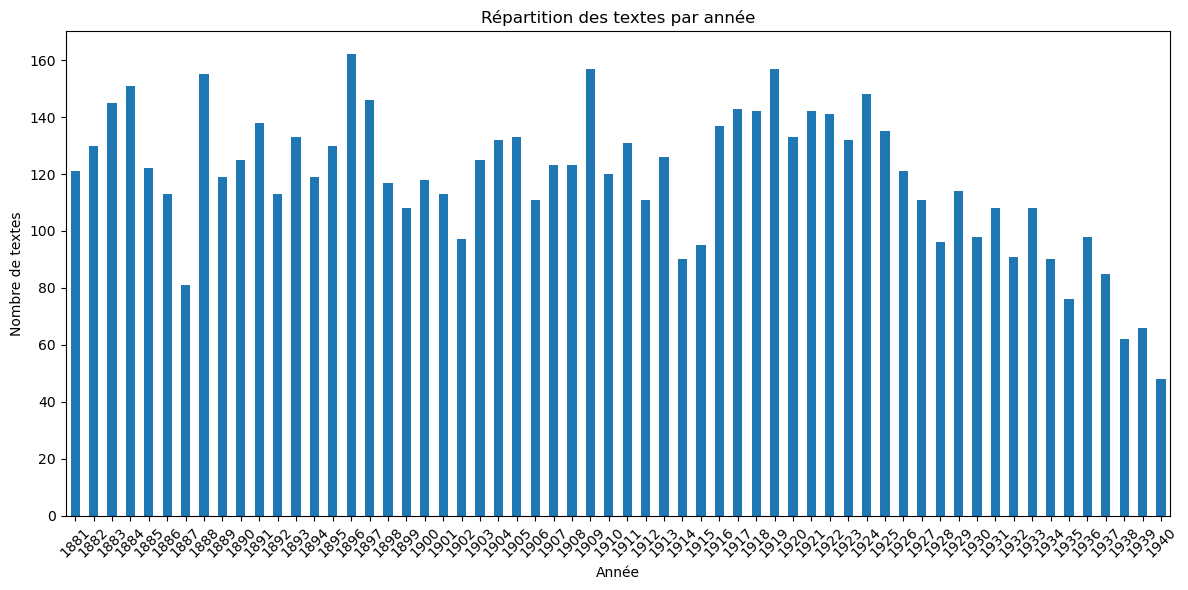